In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils import class_weight

# ===================================================================
# CONFIGURATION
# ===================================================================
# Input directory provided by Kaggle
INPUT_DIR = "/kaggle/input/biofilm-train-labelled"
# Writable directory for processed data and outputs
WORKING_DIR = "/kaggle/working/"

# Original (flat) validation and test paths
FLAT_VAL_DIR = os.path.join(INPUT_DIR, "valid")
FLAT_TEST_DIR = os.path.join(INPUT_DIR, "test")

# Paths for newly structured directories
TRAIN_DIR = os.path.join(INPUT_DIR, "train_labelled")
STRUCTURED_VAL_DIR = os.path.join(WORKING_DIR, "valid_structured")
STRUCTURED_TEST_DIR = os.path.join(WORKING_DIR, "test_structured")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

# ===================================================================
# STEP 1: CREATE STRUCTURED DIRECTORIES FOR VALID & TEST SETS
# ===================================================================
print("--- Structuring Validation and Test directories ---")
# Get class names from the already structured training directory
class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])

def create_structured_directory(source_dir, dest_dir, class_names):
    """Reads a flat directory, infers class from filename, and copies to a structured directory."""
    if os.path.exists(dest_dir):
        shutil.rmtree(dest_dir)
    os.makedirs(dest_dir)
    for class_name in class_names:
        os.makedirs(os.path.join(dest_dir, class_name), exist_ok=True)

    copied_count = 0
    for filename in os.listdir(source_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Infer class by checking if a class name is in the filename
            found_class = None
            for class_name in class_names:
                if class_name in filename:
                    found_class = class_name
                    break
            
            if found_class:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(dest_dir, found_class, filename)
                shutil.copy(source_path, dest_path)
                copied_count += 1
    print(f"Structured {copied_count} images for {os.path.basename(source_dir)}.")

create_structured_directory(FLAT_VAL_DIR, STRUCTURED_VAL_DIR, class_names)
create_structured_directory(FLAT_TEST_DIR, STRUCTURED_TEST_DIR, class_names)

# ===================================================================
# STEP 2: LOAD DATASETS FROM CORRECTLY STRUCTURED DIRECTORIES
# ===================================================================
print("\n--- Loading All Datasets ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    STRUCTURED_VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    STRUCTURED_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# ===================================================================
# STEP 3: HANDLE CLASS IMBALANCE
# ===================================================================
print("\n--- Calculating Class Weights ---")
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
class_weights_array = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(class_weights_array))

# ===================================================================
# STEP 4: BUILD MODEL WITH TRANSFER LEARNING & AUGMENTATION
# ===================================================================
print("\n--- Building Model with EfficientNetB0 ---")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

base_model = applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===================================================================
# STEP 5: TRAIN THE MODEL
# ===================================================================
print("\n--- Starting Model Training ---")
early_stopping = callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")
reduce_lr = callbacks.ReduceLROnPlateau(patience=3, monitor="val_loss")

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, class_weight=class_weights, callbacks=[early_stopping, reduce_lr])

# ===================================================================
# STEP 6: EVALUATE THE FINAL MODEL
# ===================================================================
print("\n--- Final Model Evaluation ---")
loss, accuracy = model.evaluate(test_ds)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final Test F1-Score (Macro): {f1_macro:.4f}")
print("\nFinal Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ===================================================================
# STEP 7: SAVE ARTIFACTS AND VISUALIZE
# ===================================================================
print("\n--- Saving Model and Visualizations ---")
model.save(os.path.join(WORKING_DIR, "final_model.h5"))
model.save_weights(os.path.join(WORKING_DIR, "final_model.weights.h5"))

pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("Model Training History")
plt.savefig(os.path.join(WORKING_DIR, "training_history.png"))
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.title('Final Confusion Matrix', fontsize=16)
plt.savefig(os.path.join(WORKING_DIR, "confusion_matrix.png"))
plt.show()

print(f"\n✅ All outputs saved to: {WORKING_DIR}")

--- Structuring Validation and Test directories ---
Structured 45 images for valid.
Structured 25 images for test.

--- Loading All Datasets ---
Found 2274 files belonging to 8 classes.
Found 45 files belonging to 8 classes.
Found 25 files belonging to 8 classes.

--- Calculating Class Weights ---

--- Building Model with EfficientNetB0 ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Starting Model Training ---
Epoch 1/50


E0000 00:00:1752993564.245439      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1752993566.718794     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.3001 - loss: 1.7073 - val_accuracy: 0.3556 - val_loss: 1.5922 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.4356 - loss: 1.1741 - val_accuracy: 0.4667 - val_loss: 1.4491 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5110 - loss: 1.0678 - val_accuracy: 0.4000 - val_loss: 1.4360 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.4951 - loss: 0.9757 - val_accuracy: 0.5556 - val_loss: 1.3128 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5517 - loss: 0.9028 - val_accuracy: 0.4444 - val_loss: 1.3836 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5930 - loss: 0.8169 - val_accuracy: 0.5111 - val_loss: 1.1529 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.5802 - loss: 0.8114 - val_accuracy: 0.

ValueError: Number of classes, 5, does not match size of target_names, 8. Try specifying the labels parameter

--- Combining all images and labels from the original dataset ---
Total combined images: 2393
Total unique classes found (8): ['NC1', 'NC6', 'NC_2', 'NC_3', 'NC_4', 'NC_5', 'control', 'vial8 DNA']

--- Performing a new, stratified 80-10-10 split ---

--- Creating the final structured dataset for training ---
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.

--- Loading final datasets and calculating class weights ---
Found 1914 files belonging to 8 classes.
Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with Transfer Learning (EfficientNetB0) ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Starting model training ---
Epoch 1/1000


E0000 00:00:1752998197.001251      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.2683 - loss: 1.8234 - val_accuracy: 0.5941 - val_loss: 1.1770 - learning_rate: 0.0010
Epoch 2/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.4415 - loss: 1.2709 - val_accuracy: 0.6276 - val_loss: 0.9667 - learning_rate: 0.0010
Epoch 3/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.5077 - loss: 1.0978 - val_accuracy: 0.6067 - val_loss: 0.9685 - learning_rate: 0.0010
Epoch 4/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.5415 - loss: 1.0510 - val_accuracy: 0.6109 - val_loss: 0.9416 - learning_rate: 0.0010
Epoch 5/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.5433 - loss: 0.9432 - val_accuracy: 0.7322 - val_loss: 0.7298 - learning_rate: 0.0010
Epoch 6/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.5915 - loss: 0.8578 - val_accuracy: 0.6151 - val_loss: 0.8782 - learning_rate: 0.0010
Epoch 7/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.5866 - loss: 0.8672 - val

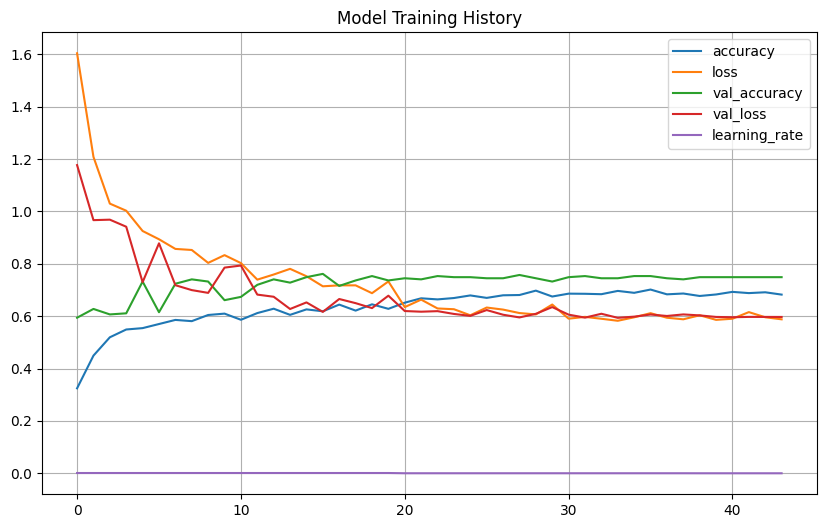

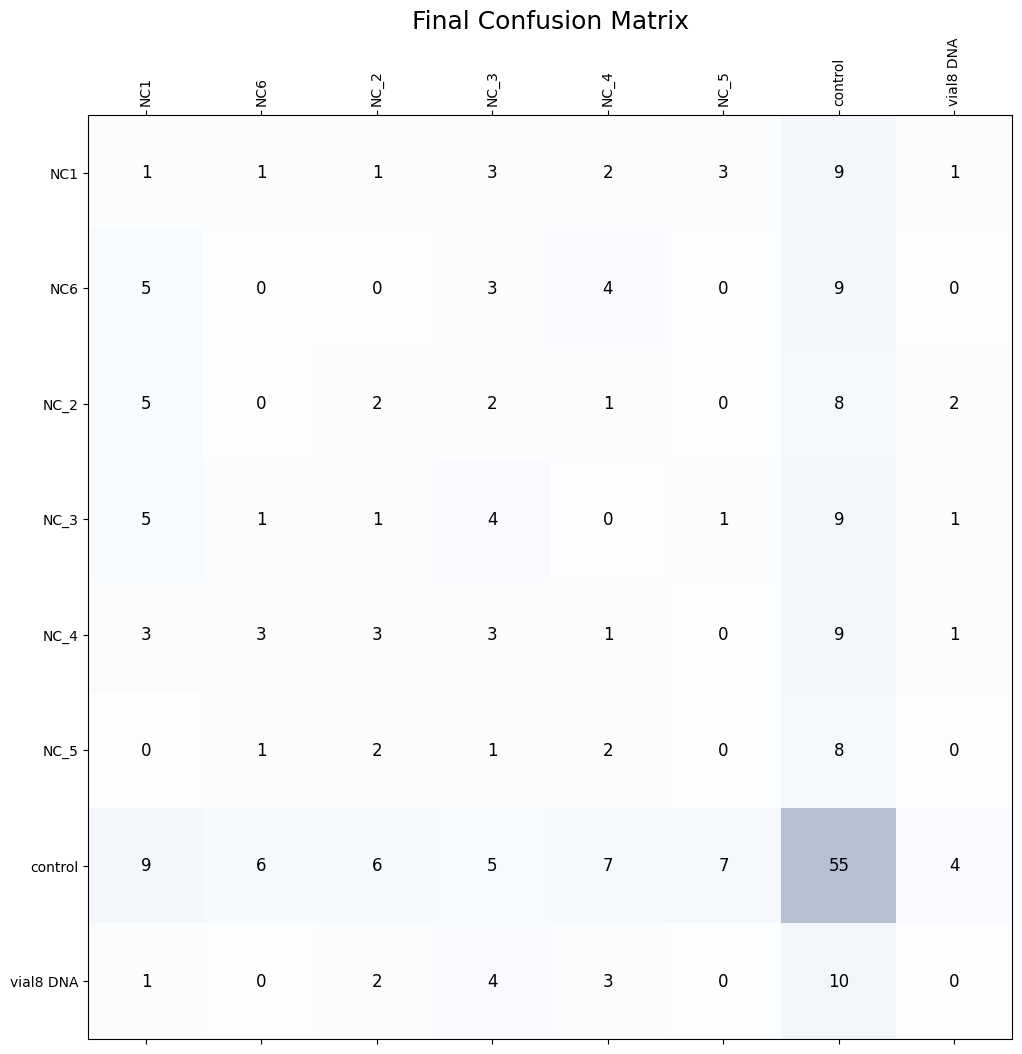


✅ All outputs have been saved to the directory: /kaggle/working/


In [4]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils import class_weight

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
# Path to the dataset provided by Kaggle, based on your screenshot
INPUT_DIR = "/kaggle/input/biofilm-dataset"
# Writable directory for processed data and all final outputs
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 1000 # Increased for better convergence, with early stopping
LEARNING_RATE = 0.001

# ===================================================================
# STEP 2: COMBINE ALL DATA AND CREATE NEW, BALANCED SPLITS
# ===================================================================
print("--- Combining all images and labels from the original dataset ---")
all_image_paths = []
all_labels = []
class_name_map = {}

# Find all COCO json files and their corresponding image directories
coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    for name in files:
        if name == "_annotations.coco.json":
            subset = os.path.basename(root)
            coco_files[subset] = os.path.join(root, name)

# Parse each COCO file and collect all data
for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    if not class_name_map:
        class_name_map = cat_id_to_name
    
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name'])} for img in coco_data['images']}
    for ann in coco_data['annotations']:
        img_id, cat_id = ann['image_id'], ann['category_id']
        if img_id in img_id_to_info:
            img_id_to_info[img_id]['label'] = cat_id_to_name[cat_id]
            
    for img_id, info in img_id_to_info.items():
        if 'label' in info and os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(info['label'])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}")
print(f"Total unique classes found ({len(all_class_names)}): {all_class_names}")

print("\n--- Performing a new, stratified 80-10-10 split ---")
# Split 1: 80% train, 20% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
# Split 2: 10% validation, 10% test from the temp set
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE THE FINAL, STRUCTURED DATASET DIRECTORY
# ===================================================================
print("\n--- Creating the final structured dataset for training ---")
if os.path.exists(FINAL_DATASET_DIR):
    shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels, class_names):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for class_name in class_names:
        os.makedirs(os.path.join(subset_dir, class_name), exist_ok=True)
    for path, label in zip(paths, labels):
        dest_path = os.path.join(subset_dir, label, os.path.basename(path))
        shutil.copy(path, dest_path)
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels, all_class_names)
create_subset("valid", val_paths, val_labels, all_class_names)
create_subset("test", test_paths, test_labels, all_class_names)

# ===================================================================
# STEP 4: LOAD DATASETS AND HANDLE CLASS IMBALANCE
# ===================================================================
print("\n--- Loading final datasets and calculating class weights ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')

# Calculate class weights from the new training set
train_labels_new = np.concatenate([y for x, y in train_ds], axis=0)
class_weights_array = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels_new), y=train_labels_new)
class_weights = dict(enumerate(class_weights_array))

# ===================================================================
# STEP 5: BUILD THE HIGH-PERFORMANCE MODEL
# ===================================================================
print("\n--- Building model with Transfer Learning (EfficientNetB0) ---")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
], name="data_augmentation")

base_model = applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===================================================================
# STEP 6: TRAIN THE MODEL WITH SMART CALLBACKS
# ===================================================================
print("\n--- Starting model training ---")
early_stopping = callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")
reduce_lr = callbacks.ReduceLROnPlateau(patience=4, monitor="val_loss")

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, class_weight=class_weights, callbacks=[early_stopping, reduce_lr])

# ===================================================================
# STEP 7: COMPREHENSIVE EVALUATION
# ===================================================================
print("\n--- Final Model Evaluation on the Test Set ---")
loss, accuracy = model.evaluate(test_ds)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final Test F1-Score (Macro): {f1_macro:.4f}")
print("\nFinal Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 8: SAVE ALL ARTIFACTS AND VISUALIZE RESULTS
# ===================================================================
print("\n--- Saving model, weights, and visualizations ---")
model.save(os.path.join(OUTPUT_DIR, "final_model.h5"))
model.save_weights(os.path.join(OUTPUT_DIR, "final_model.weights.h5"))

pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("Model Training History")
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()

print(f"\n✅ All outputs have been saved to the directory: {OUTPUT_DIR}")

--- Combining all images and labels from the original dataset ---
Total combined images: 2393
Total unique classes (8): ['NC1', 'NC6', 'NC_2', 'NC_3', 'NC_4', 'NC_5', 'control', 'vial8 DNA']

--- Performing a new, stratified 80-10-10 split ---

--- Creating the final structured dataset for training ---
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.

--- Loading final datasets and calculating class weights ---
Found 1914 files belonging to 8 classes.
Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with Transfer Learning (EfficientNetB0) ---

--- Starting Phase 1 Training (Feature Extraction) ---
Epoch 1/500


E0000 00:00:1752998758.090845      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.2233 - loss: 1.9666 - val_accuracy: 0.5439 - val_loss: 1.2585
Epoch 2/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.4032 - loss: 1.3580 - val_accuracy: 0.6778 - val_loss: 1.0173
Epoch 3/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.4640 - loss: 1.1877 - val_accuracy: 0.6862 - val_loss: 0.8891
Epoch 4/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.5219 - loss: 1.0963 - val_accuracy: 0.7280 - val_loss: 0.7950
Epoch 5/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.5413 - loss: 1.0150 - val_accuracy: 0.6820 - val_loss: 0.7822
Epoch 6/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5564 - loss: 0.9904 - val_accuracy: 0.7238 - val_loss: 0.7964
Epoch 7/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.5601 - loss: 0.9495 - val_accuracy: 0.7573 - val_loss: 0.6733
Epoch 8/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.5730 - loss: 0.9321 - val_accuracy: 0.7615 - va

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 4,170,340 (15.91 MB)

 Non-trainable params: 209,223 (817.28 KB)

Epoch 65/1000


E0000 00:00:1752999157.469318      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 232ms/step - accuracy: 0.4251 - loss: 3.7985 - val_accuracy: 0.7406 - val_loss: 0.7443
Epoch 66/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.4638 - loss: 2.7833 - val_accuracy: 0.6862 - val_loss: 1.1298
Epoch 67/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.4660 - loss: 2.4555 - val_accuracy: 0.6444 - val_loss: 1.3684
Epoch 68/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.4822 - loss: 2.1351 - val_accuracy: 0.6151 - val_loss: 1.3821
Epoch 69/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.4784 - loss: 1.9744 - val_accuracy: 0.6067 - val_loss: 1.3051
Epoch 70/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.4723 - loss: 1.8794 - val_accuracy: 0.6025 - val_loss: 1.2327
Epoch 71/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.4927 - loss: 1.7555 - val_accuracy: 0.6151 - val_loss: 1.1635
Epoch 72/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.5041 - loss: 1.5886 

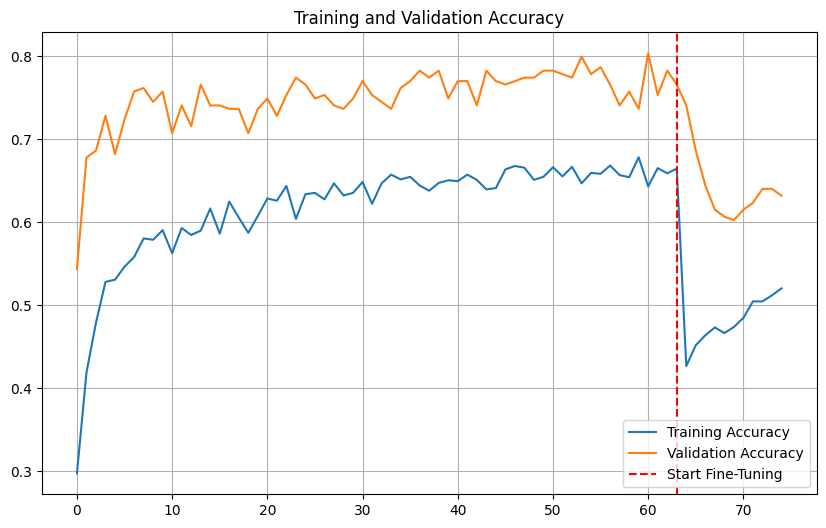

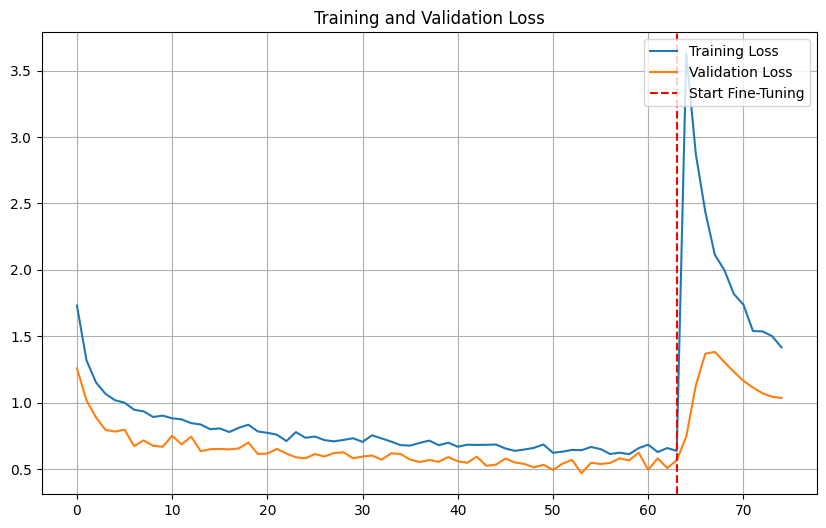

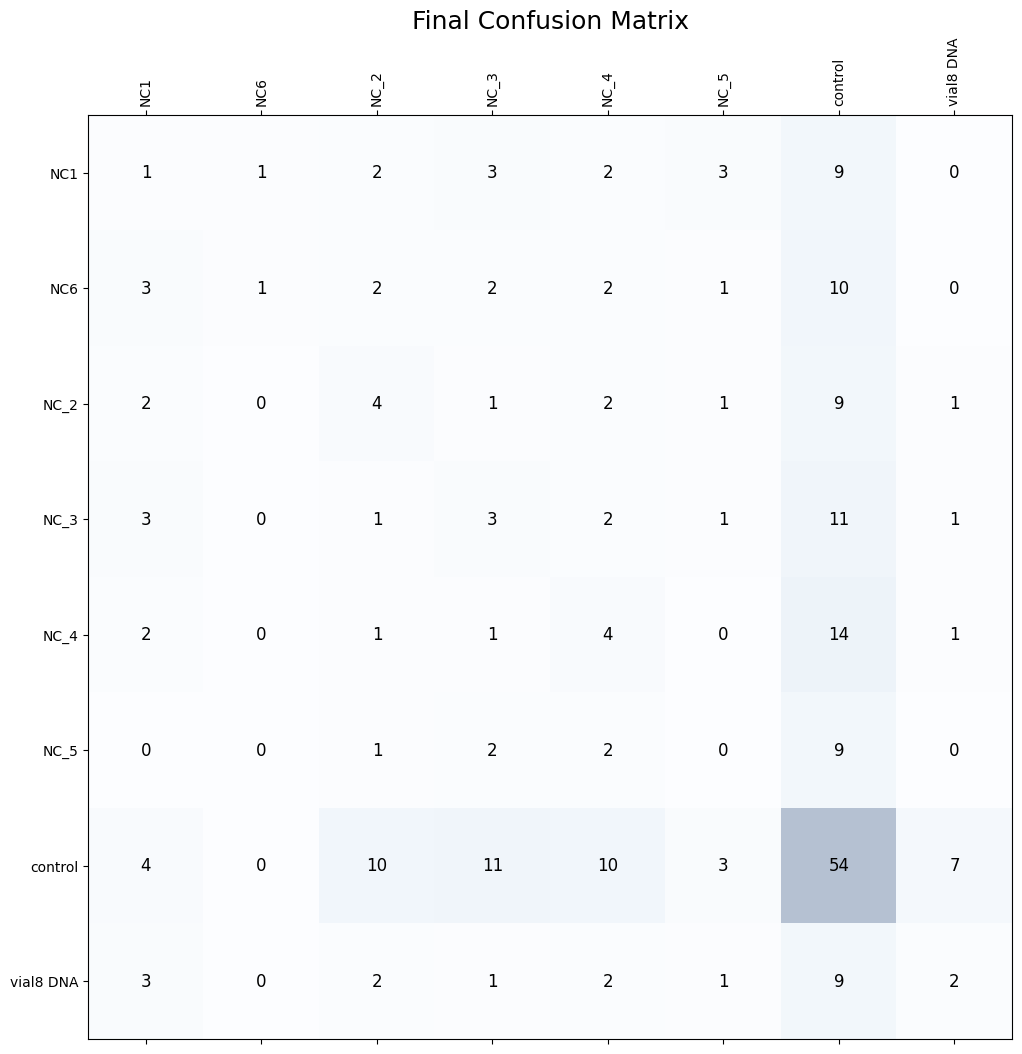


✅ All outputs have been saved to the directory: /kaggle/working/


In [5]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils import class_weight

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
# Path to the dataset provided by Kaggle, based on your screenshot
INPUT_DIR = "/kaggle/input/biofilm-dataset"
# Writable directory for processed data and all final outputs
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 500   # Epochs for the first phase
FINETUNE_EPOCHS = 500  # Epochs for the fine-tuning phase
INITIAL_LR = 0.001
FINETUNE_LR = 1e-5

# ===================================================================
# STEP 2: COMBINE ALL DATA AND CREATE NEW, BALANCED SPLITS
# ===================================================================
print("--- Combining all images and labels from the original dataset ---")
all_image_paths = []
all_labels = []

# Find and parse all COCO json files to collect data
coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    if "_annotations.coco.json" in files:
        subset = os.path.basename(root)
        coco_files[subset] = os.path.join(root, "_annotations.coco.json")

for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name']), 'label_id': ann['category_id']}
                      for img in coco_data['images'] for ann in coco_data['annotations'] if ann['image_id'] == img['id']}
                      
    for img_id, info in img_id_to_info.items():
        if os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(cat_id_to_name[info['label_id']])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}")
print(f"Total unique classes ({len(all_class_names)}): {all_class_names}")

print("\n--- Performing a new, stratified 80-10-10 split ---")
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE THE FINAL, STRUCTURED DATASET DIRECTORY
# ===================================================================
print("\n--- Creating the final structured dataset for training ---")
if os.path.exists(FINAL_DATASET_DIR):
    shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels, class_names):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for class_name in class_names:
        os.makedirs(os.path.join(subset_dir, class_name), exist_ok=True)
    for path, label in zip(paths, labels):
        shutil.copy(path, os.path.join(subset_dir, label, os.path.basename(path)))
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels, all_class_names)
create_subset("valid", val_paths, val_labels, all_class_names)
create_subset("test", test_paths, test_labels, all_class_names)

# ===================================================================
# STEP 4: LOAD DATASETS AND HANDLE CLASS IMBALANCE
# ===================================================================
print("\n--- Loading final datasets and calculating class weights ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')

train_labels_new = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(train_labels_new), y=train_labels_new)))

# ===================================================================
# STEP 5: BUILD THE HIGH-PERFORMANCE MODEL
# ===================================================================
print("\n--- Building model with Transfer Learning (EfficientNetB0) ---")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.4),
    layers.RandomZoom(0.4),
    layers.RandomContrast(0.3),
], name="data_augmentation")

base_model = applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False # Start with the base model frozen

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=INITIAL_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ===================================================================
# STEP 6: PHASE 1 TRAINING (FEATURE EXTRACTION)
# ===================================================================
print("\n--- Starting Phase 1 Training (Feature Extraction) ---")
history = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")]
)
initial_epochs_trained = len(history.history['loss'])

# ===================================================================
# STEP 7: PHASE 2 TRAINING (FINE-TUNING)
# ===================================================================
print("\n--- Starting Phase 2 Training (Fine-Tuning) ---")
base_model.trainable = True # Unfreeze the base model

# Fine-tune from this layer onwards
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile the model with a very low learning rate
model.compile(optimizer=optimizers.Adam(learning_rate=FINETUNE_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history_fine_tune = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS + FINETUNE_EPOCHS,
    initial_epoch=initial_epochs_trained,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")]
)

# ===================================================================
# STEP 8: COMPREHENSIVE EVALUATION
# ===================================================================
print("\n--- Final Model Evaluation on the Test Set ---")
loss, accuracy = model.evaluate(test_ds)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final Test F1-Score (Macro): {f1_macro:.4f}")

all_labels = list(range(len(all_class_names)))
print("\nFinal Test Classification Report:")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 9: SAVE ALL ARTIFACTS AND VISUALIZE RESULTS
# ===================================================================
print("\n--- Saving model, weights, and visualizations ---")
model.save(os.path.join(OUTPUT_DIR, "final_model.h5"))
model.save_weights(os.path.join(OUTPUT_DIR, "final_model.weights.h5"))

# Combine histories for plotting
acc = history.history['accuracy'] + history_fine_tune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
loss = history.history['loss'] + history_fine_tune.history['loss']
val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_history.png"))
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "loss_history.png"))
plt.show()

cm = confusion_matrix(y_true, y_pred, labels=all_labels)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()

print(f"\n✅ All outputs have been saved to the directory: {OUTPUT_DIR}")

2025-07-20 11:43:31.379277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753011811.737461      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753011811.843845      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


--- Combining all images and labels from the original dataset ---
Total combined images: 2393
Total unique classes (8): ['NC1', 'NC6', 'NC_2', 'NC_3', 'NC_4', 'NC_5', 'control', 'vial8 DNA']

--- Performing a new, stratified 80-10-10 split ---

--- Creating the final structured dataset for training ---
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.

--- Loading final datasets and calculating class weights ---
Found 1914 files belonging to 8 classes.


I0000 00:00:1753011843.134513      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753011843.135340      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with Transfer Learning (EfficientNetB0) ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Starting Phase 1 Training (Feature Extraction) ---
Epoch 1/100


E0000 00:00:1753011867.581470      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1753011871.004022     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

 Trainable params: 4,170,340 (15.91 MB)

 Non-trainable params: 209,223 (817.28 KB)

Epoch 72/200


E0000 00:00:1753012313.711241      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


60/60 ━━━━━━━━━━━━━━━━━━━━ 57s 245ms/step - accuracy: 0.3127 - loss: 3.7092 - val_accuracy: 0.7280 - val_loss: 0.8525
Epoch 73/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.3549 - loss: 2.8780 - val_accuracy: 0.6444 - val_loss: 1.1747
Epoch 74/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.4082 - loss: 2.3900 - val_accuracy: 0.6402 - val_loss: 1.3895
Epoch 75/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.4127 - loss: 2.0130 - val_accuracy: 0.6151 - val_loss: 1.3621
Epoch 76/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.4330 - loss: 2.1395 - val_accuracy: 0.6360 - val_loss: 1.2836
Epoch 77/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.4360 - loss: 1.8251 - val_accuracy: 0.6444 - val_loss: 1.2429
Epoch 78/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.4667 - loss: 1.6681 - val_accuracy: 0.6360 - val_loss: 1.1953
Epoch 79/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.4751 - loss: 1.7019 - val_a

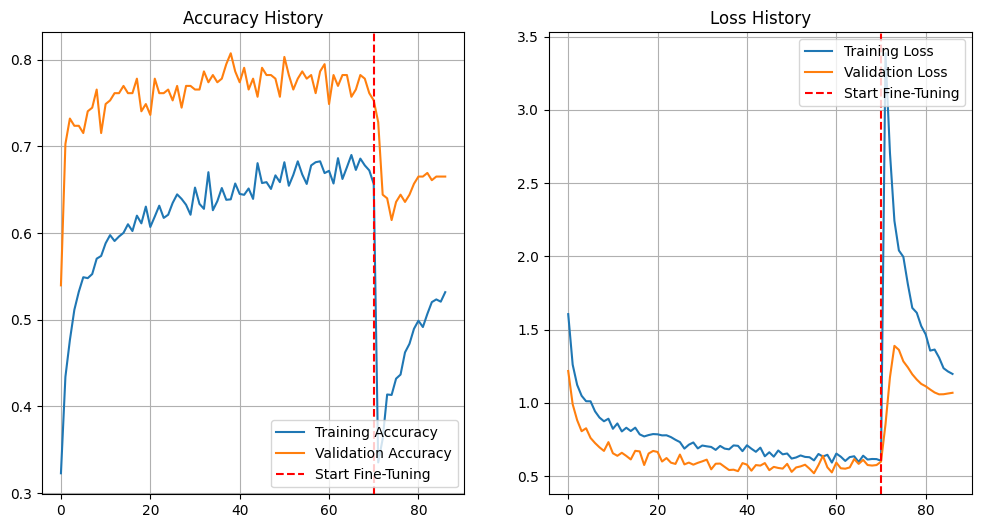

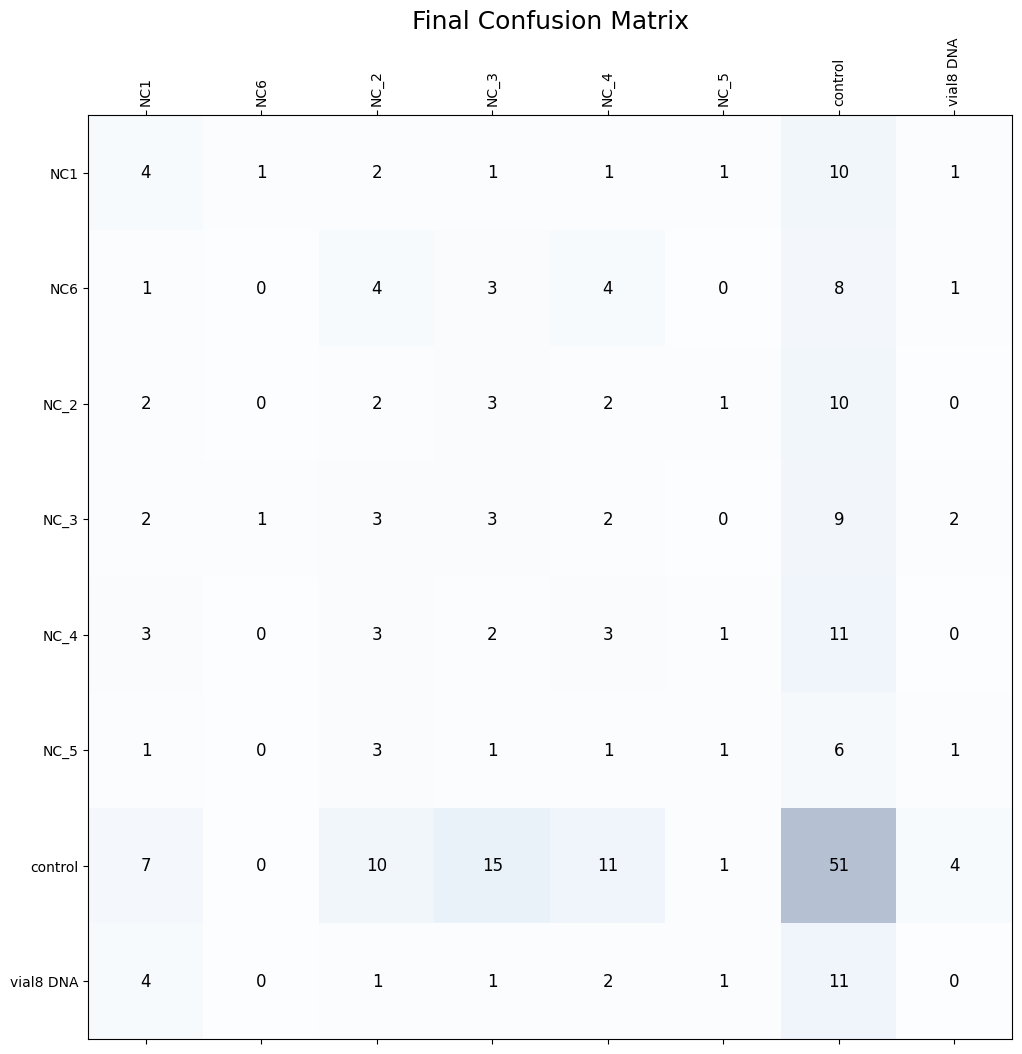


✅ All outputs have been saved to the directory: /kaggle/working/


In [1]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils import class_weight

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
# Path to the dataset provided by Kaggle
INPUT_DIR = "/kaggle/input/biofilm-dataset"
# Writable directory for processed data and all final outputs
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 100   # Max epochs for the first phase
FINETUNE_EPOCHS = 100  # Max epochs for the fine-tuning phase
INITIAL_LR = 0.001
FINETUNE_LR = 1e-5     # Very low learning rate for fine-tuning

# ===================================================================
# STEP 2: COMBINE ALL DATA AND CREATE NEW, BALANCED SPLITS
# ===================================================================
print("--- Combining all images and labels from the original dataset ---")
all_image_paths = []
all_labels = []

# Find and parse all COCO json files to collect data
coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    if "_annotations.coco.json" in files:
        subset = os.path.basename(root)
        coco_files[subset] = os.path.join(root, "_annotations.coco.json")

for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name']), 'label_id': ann['category_id']}
                      for img in coco_data['images'] for ann in coco_data['annotations'] if ann['image_id'] == img['id']}
                      
    for img_id, info in img_id_to_info.items():
        if os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(cat_id_to_name[info['label_id']])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}")
print(f"Total unique classes ({len(all_class_names)}): {all_class_names}")

print("\n--- Performing a new, stratified 80-10-10 split ---")
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE THE FINAL, STRUCTURED DATASET DIRECTORY
# ===================================================================
print("\n--- Creating the final structured dataset for training ---")
if os.path.exists(FINAL_DATASET_DIR):
    shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels, class_names):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for class_name in class_names:
        os.makedirs(os.path.join(subset_dir, class_name), exist_ok=True)
    for path, label in zip(paths, labels):
        shutil.copy(path, os.path.join(subset_dir, label, os.path.basename(path)))
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels, all_class_names)
create_subset("valid", val_paths, val_labels, all_class_names)
create_subset("test", test_paths, test_labels, all_class_names)

# ===================================================================
# STEP 4: LOAD DATASETS AND HANDLE CLASS IMBALANCE
# ===================================================================
print("\n--- Loading final datasets and calculating class weights ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')

train_labels_new = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(train_labels_new), y=train_labels_new)))

# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# ===================================================================
# STEP 5: BUILD THE HIGH-PERFORMANCE MODEL
# ===================================================================
print("\n--- Building model with Transfer Learning (EfficientNetB0) ---")
# More aggressive augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.4),
    layers.RandomZoom(0.4),
    layers.RandomContrast(0.3),
], name="data_augmentation")

base_model = applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False # Start with the base model frozen

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x) # Preprocessing for EfficientNet
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Increased dropout for more regularization
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=INITIAL_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ===================================================================
# STEP 6: PHASE 1 TRAINING (FEATURE EXTRACTION)
# ===================================================================
print("\n--- Starting Phase 1 Training (Feature Extraction) ---")
history = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")]
)
initial_epochs_trained = len(history.history['loss'])

# ===================================================================
# STEP 7: PHASE 2 TRAINING (FINE-TUNING)
# ===================================================================
print("\n--- Starting Phase 2 Training (Fine-Tuning) ---")
base_model.trainable = True # Unfreeze the base model

# Fine-tune from this layer onwards
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile the model with a very low learning rate
model.compile(optimizer=optimizers.Adam(learning_rate=FINETUNE_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history_fine_tune = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS + FINETUNE_EPOCHS,
    initial_epoch=initial_epochs_trained,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")]
)

# ===================================================================
# STEP 8: COMPREHENSIVE EVALUATION
# ===================================================================
print("\n--- Final Model Evaluation on the Test Set ---")
loss, accuracy = model.evaluate(test_ds)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final Test F1-Score (Macro): {f1_macro:.4f}")

all_labels = list(range(len(all_class_names)))
print("\nFinal Test Classification Report:")
print(classification_report(y_true, y_pred, labels=all_labels, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 9: SAVE ALL ARTIFACTS AND VISUALIZE RESULTS
# ===================================================================
print("\n--- Saving model, weights, and visualizations ---")
model.save(os.path.join(OUTPUT_DIR, "final_model.h5"))
model.save_weights(os.path.join(OUTPUT_DIR, "final_model.weights.h5"))

# Combine histories for plotting
acc = history.history['accuracy'] + history_fine_tune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
loss = history.history['loss'] + history_fine_tune.history['loss']
val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Accuracy History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Loss History')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()


cm = confusion_matrix(y_true, y_pred, labels=all_labels)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()

print(f"\n✅ All outputs have been saved to the directory: {OUTPUT_DIR}")

In [ ]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from sklearn.utils import class_weight

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
INPUT_DIR = "/kaggle/input/biofilm-dataset"
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters
IMG_SIZE = (300, 300) # EfficientNetB3 prefers larger image sizes
BATCH_SIZE = 16 # Smaller batch size for a larger model
INITIAL_EPOCHS = 50
FINETUNE_EPOCHS = 50
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

# ===================================================================
# STEP 2: COMBINE DATA & CREATE NEW STRATIFIED SPLITS
# ===================================================================
print("--- Combining all data and creating new balanced splits ---")
all_image_paths, all_labels = [], []
coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    if "_annotations.coco.json" in files:
        coco_files[os.path.basename(root)] = os.path.join(root, "_annotations.coco.json")

for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name']), 'label_id': ann['category_id']}
                      for img in coco_data['images'] for ann in coco_data['annotations'] if ann['image_id'] == img['id']}
                      
    for img_id, info in img_id_to_info.items():
        if os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(cat_id_to_name[info['label_id']])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}, Total unique classes: {len(all_class_names)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE FINAL STRUCTURED DATASET
# ===================================================================
if os.path.exists(FINAL_DATASET_DIR): shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for path, label in zip(paths, labels):
        os.makedirs(os.path.join(subset_dir, label), exist_ok=True)
        shutil.copy(path, os.path.join(subset_dir, label, os.path.basename(path)))
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels)
create_subset("valid", val_paths, val_labels)
create_subset("test", test_paths, test_labels)

# ===================================================================
# STEP 4: DATA LOADERS AND FOCAL LOSS
# ===================================================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False).prefetch(buffer_size=AUTOTUNE)

# Focal Loss Implementation
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(all_class_names))
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        loss = -alpha * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return focal_loss_fn

# ===================================================================
# STEP 5: BUILD AND TRAIN THE MODEL (TWO-STAGE FINE-TUNING)
# ===================================================================
print("\n--- Building model with EfficientNetB3 ---")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5), layers.RandomZoom(0.5), layers.RandomContrast(0.4)
], name="data_augmentation")

base_model = applications.EfficientNetB3(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=INITIAL_LR), loss=focal_loss(), metrics=['accuracy'])

print("\n--- Starting Phase 1 Training (Feature Extraction) ---")
history = model.fit(train_ds, epochs=INITIAL_EPOCHS, validation_data=val_ds,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])
initial_epochs_trained = len(history.history['loss'])

print("\n--- Starting Phase 2 Training (Fine-Tuning) ---")
base_model.trainable = True
model.compile(optimizer=optimizers.Adam(learning_rate=FINETUNE_LR), loss=focal_loss(), metrics=['accuracy'])
history_fine_tune = model.fit(train_ds, epochs=INITIAL_EPOCHS + FINETUNE_EPOCHS, initial_epoch=initial_epochs_trained, validation_data=val_ds,
                              callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])

# ===================================================================
# STEP 6: EVALUATION WITH TEST-TIME AUGMENTATION (TTA)
# ===================================================================
print("\n--- Final Evaluation with Test-Time Augmentation ---")
tta_steps = 5
tta_predictions = []
test_images_ds = test_ds.map(lambda image, label: image)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

for _ in range(tta_steps):
    predictions = model.predict(test_images_ds)
    tta_predictions.append(predictions)

avg_predictions = np.mean(tta_predictions, axis=0)
y_pred = np.argmax(avg_predictions, axis=1)

# CORRECTED: Ensure accuracy_score is imported and used
accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final TTA Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final TTA Test F1-Score (Macro): {f1_macro:.4f}")
print("\nFinal TTA Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 7: SAVE ARTIFACTS AND VISUALIZE
# ===================================================================
print("\n--- Saving final model and visualizations ---")
model.save(os.path.join(OUTPUT_DIR, "final_model_finetuned.h5"))
model.save_weights(os.path.join(OUTPUT_DIR, "final_model_finetuned.weights.h5"))

# Combine histories for plotting
acc = history.history['accuracy'] + history_fine_tune.history.get('accuracy', [])
val_acc = history.history['val_accuracy'] + history_fine_tune.history.get('val_accuracy', [])
loss = history.history['loss'] + history_fine_tune.history.get('loss', [])
val_loss = history.history['val_loss'] + history_fine_tune.history.get('val_loss', [])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Accuracy History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Loss History')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix (with TTA)', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_final.png"))
plt.show()

print(f"\n✅ All outputs saved to: {OUTPUT_DIR}")

--- Combining all data and creating new balanced splits ---
Total combined images: 2393, Total unique classes: 8
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.
Found 1914 files belonging to 8 classes.
Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with EfficientNetB3 ---

--- Starting Phase 1 Training (Feature Extraction) ---
Epoch 1/50


E0000 00:00:1753019711.379248      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 55s 215ms/step - accuracy: 0.4124 - loss: 0.2793 - val_accuracy: 0.7113 - val_loss: 0.1223
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.5994 - loss: 0.1617 - val_accuracy: 0.7364 - val_loss: 0.1001
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.6289 - loss: 0.1365 - val_accuracy: 0.7448 - val_loss: 0.0880
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.6742 - loss: 0.1194 - val_accuracy: 0.7741 - val_loss: 0.0793
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.6744 - loss: 0.1182 - val_accuracy: 0.7448 - val_loss: 0.0946
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.6947 - loss: 0.1119 - val_accuracy: 0.7782 - val_loss: 0.0814
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step - accuracy: 0.6799 - loss: 0.1134 - val_accuracy: 0.7657 - val_loss: 0.0751
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/step - accuracy: 0.6856 - loss: 0.1056 - val

E0000 00:00:1753020340.450330      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 187s 698ms/step - accuracy: 0.3835 - loss: 0.4364 - val_accuracy: 0.6695 - val_loss: 0.1421
Epoch 30/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 644ms/step - accuracy: 0.4675 - loss: 0.2850 - val_accuracy: 0.6109 - val_loss: 0.1757
Epoch 31/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 643ms/step - accuracy: 0.5199 - loss: 0.2227 - val_accuracy: 0.6234 - val_loss: 0.1720
Epoch 32/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 644ms/step - accuracy: 0.5442 - loss: 0.2060 - val_accuracy: 0.6527 - val_loss: 0.1657
Epoch 33/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 642ms/step - accuracy: 0.5917 - loss: 0.1799 - val_accuracy: 0.6444 - val_loss: 0.1629
Epoch 34/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 642ms/step - accuracy: 0.6361 - loss: 0.1596 - val_accuracy: 0.6695 - val_loss: 0.1471
Epoch 35/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 642ms/step - accuracy: 0.6266 - loss: 0.1518 - val_accuracy: 0.6778 - val_loss: 0.1477
Epoch 36/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 77s 645ms/step - accuracy: 0.6448 - los

--- Combining all images and labels from the original dataset ---
Total combined images: 2393, Total unique classes: 8
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.
Found 1914 files belonging to 8 classes.


I0000 00:00:1753195952.664112      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753195952.664928      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with EfficientNetB3 ---
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Starting Phase 1 Training (Feature Extraction) ---
Epoch 1/50


E0000 00:00:1753195983.263944      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1753195986.617283     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


120/120 ━━━━━━━━━━━━━━━━━━━━ 56s 217ms/step - accuracy: 0.4409 - loss: 0.2732 - val_accuracy: 0.7322 - val_loss: 0.1212
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.6335 - loss: 0.1556 - val_accuracy: 0.7741 - val_loss: 0.0866
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.6588 - loss: 0.1286 - val_accuracy: 0.7657 - val_loss: 0.0893
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.7012 - loss: 0.1128 - val_accuracy: 0.7782 - val_loss: 0.0923
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.7000 - loss: 0.1116 - val_accuracy: 0.7657 - val_loss: 0.0860
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 0.7135 - loss: 0.1120 - val_accuracy: 0.7615 - val_loss: 0.0938
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.7093 - loss: 0.1096 - val_accuracy: 0.8117 - val_loss: 0.0750
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.7305 - loss: 0.1017 - val

E0000 00:00:1753196516.112641      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 177s 646ms/step - accuracy: 0.3970 - loss: 0.3824 - val_accuracy: 0.6653 - val_loss: 0.1493
Epoch 27/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 600ms/step - accuracy: 0.4912 - loss: 0.2523 - val_accuracy: 0.6276 - val_loss: 0.1606
Epoch 28/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 602ms/step - accuracy: 0.5317 - loss: 0.2191 - val_accuracy: 0.6360 - val_loss: 0.1560
Epoch 29/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 603ms/step - accuracy: 0.6019 - loss: 0.1777 - val_accuracy: 0.6318 - val_loss: 0.1540
Epoch 30/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 601ms/step - accuracy: 0.6239 - loss: 0.1571 - val_accuracy: 0.6444 - val_loss: 0.1547
Epoch 31/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 602ms/step - accuracy: 0.6182 - loss: 0.1521 - val_accuracy: 0.6444 - val_loss: 0.1444
Epoch 32/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 602ms/step - accuracy: 0.6325 - loss: 0.1446 - val_accuracy: 0.6611 - val_loss: 0.1338
Epoch 33/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 603ms/step - accuracy: 0.6560 - los

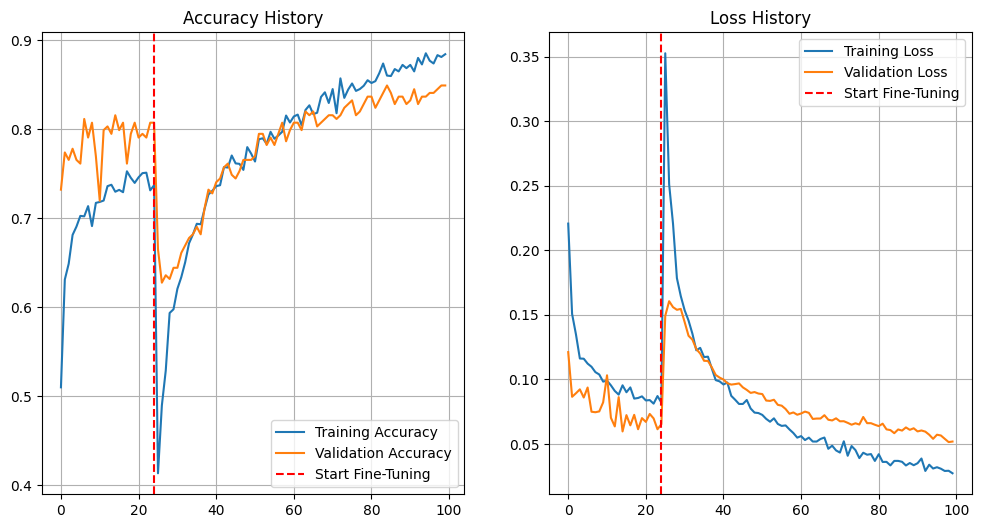

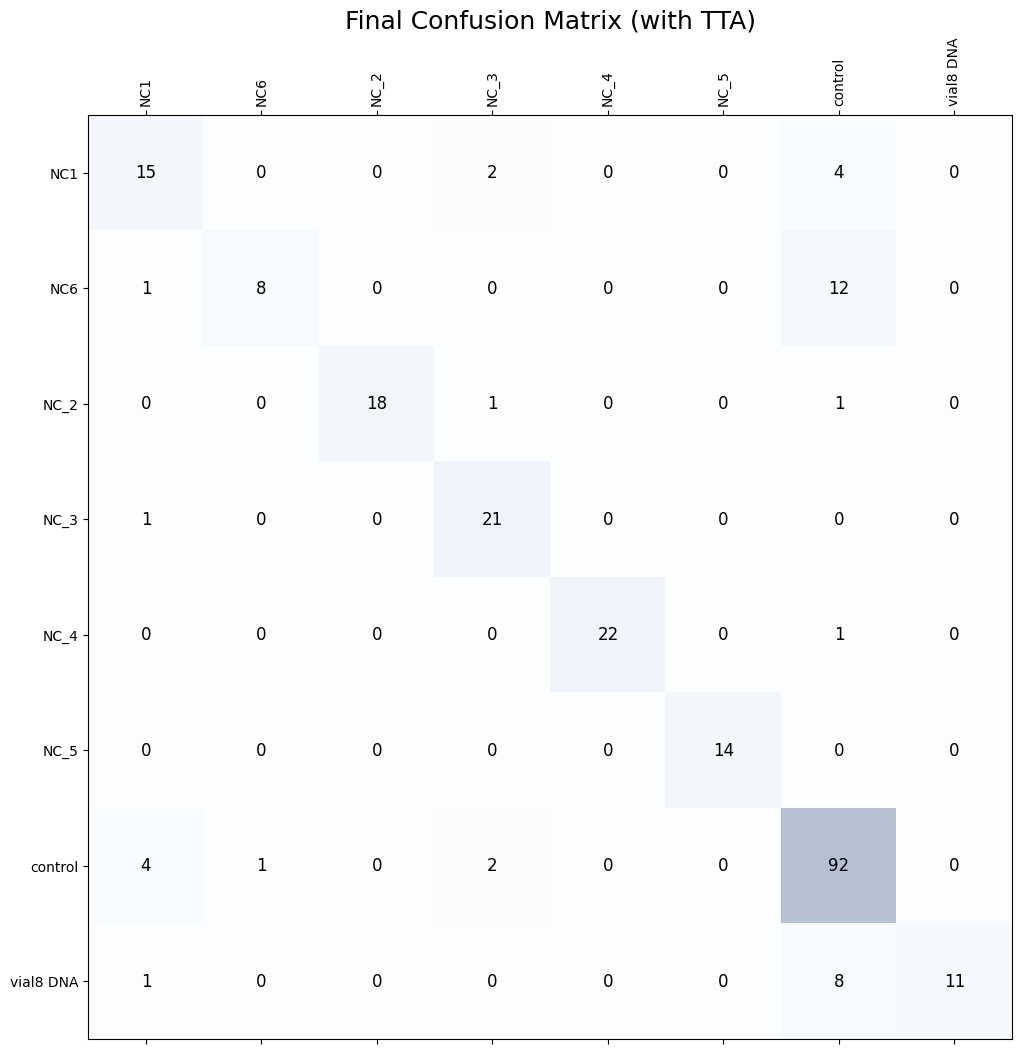


--- Preparing files for download ---
Your browser will now prompt you to download the model and weights files.


AttributeError: 'list' object has no attribute 'download'

In [2]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from google.colab import files # This library also works in Kaggle for downloads

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
# Path to the dataset provided by Kaggle
INPUT_DIR = "/kaggle/input/biofilm-dataset"
# Writable directory for processed data and all final outputs
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
INITIAL_EPOCHS = 50
FINETUNE_EPOCHS = 50
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

# ===================================================================
# STEP 2: COMBINE ALL DATA AND CREATE NEW, BALANCED SPLITS
# ===================================================================
print("--- Combining all images and labels from the original dataset ---")
all_image_paths = []
all_labels = []

coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    if "_annotations.coco.json" in files:
        subset = os.path.basename(root)
        coco_files[subset] = os.path.join(root, "_annotations.coco.json")

for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name']), 'label_id': ann['category_id']}
                      for img in coco_data['images'] for ann in coco_data['annotations'] if ann['image_id'] == img['id']}
                      
    for img_id, info in img_id_to_info.items():
        if os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(cat_id_to_name[info['label_id']])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}, Total unique classes: {len(all_class_names)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE FINAL STRUCTURED DATASET
# ===================================================================
if os.path.exists(FINAL_DATASET_DIR): shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for path, label in zip(paths, labels):
        os.makedirs(os.path.join(subset_dir, label), exist_ok=True)
        shutil.copy(path, os.path.join(subset_dir, label, os.path.basename(path)))
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels)
create_subset("valid", val_paths, val_labels)
create_subset("test", test_paths, test_labels)

# ===================================================================
# STEP 4: DATA LOADERS AND FOCAL LOSS
# ===================================================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False).prefetch(buffer_size=AUTOTUNE)

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(all_class_names))
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        loss = -alpha * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return focal_loss_fn

# ===================================================================
# STEP 5: BUILD AND TRAIN THE MODEL (TWO-STAGE FINE-TUNING)
# ===================================================================
print("\n--- Building model with EfficientNetB3 ---")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5), layers.RandomZoom(0.5), layers.RandomContrast(0.4)
], name="data_augmentation")

base_model = applications.EfficientNetB3(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=INITIAL_LR), loss=focal_loss(), metrics=['accuracy'])

print("\n--- Starting Phase 1 Training (Feature Extraction) ---")
history = model.fit(train_ds, epochs=INITIAL_EPOCHS, validation_data=val_ds,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])
initial_epochs_trained = len(history.history['loss'])

print("\n--- Starting Phase 2 Training (Fine-Tuning) ---")
base_model.trainable = True
model.compile(optimizer=optimizers.Adam(learning_rate=FINETUNE_LR), loss=focal_loss(), metrics=['accuracy'])
history_fine_tune = model.fit(train_ds, epochs=INITIAL_EPOCHS + FINETUNE_EPOCHS, initial_epoch=initial_epochs_trained, validation_data=val_ds,
                              callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])

# ===================================================================
# STEP 6: EVALUATION WITH TEST-TIME AUGMENTATION (TTA)
# ===================================================================
print("\n--- Final Evaluation with Test-Time Augmentation ---")
tta_steps = 5
tta_predictions = []
test_images_ds = test_ds.map(lambda image, label: image)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

for _ in range(tta_steps):
    predictions = model.predict(test_images_ds)
    tta_predictions.append(predictions)

avg_predictions = np.mean(tta_predictions, axis=0)
y_pred = np.argmax(avg_predictions, axis=1)

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final TTA Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final TTA Test F1-Score (Macro): {f1_macro:.4f}")
print("\nFinal TTA Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 7: SAVE ARTIFACTS AND VISUALIZE
# ===================================================================
print("\n--- Saving final model and visualizations ---")
model_path = os.path.join(OUTPUT_DIR, "final_model_finetuned.h5")
weights_path = os.path.join(OUTPUT_DIR, "final_model_finetuned.weights.h5")
model.save(model_path)
model.save_weights(weights_path)

# Combine histories for plotting
acc = history.history.get('accuracy', []) + history_fine_tune.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', []) + history_fine_tune.history.get('val_accuracy', [])
loss = history.history.get('loss', []) + history_fine_tune.history.get('loss', [])
val_loss = history.history.get('val_loss', []) + history_fine_tune.history.get('val_loss', [])

# Plotting code remains the same...
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
if initial_epochs_trained > 0:
    plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Accuracy History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
if initial_epochs_trained > 0:
    plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Loss History')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()

all_labels_for_cm = list(range(len(all_class_names)))
cm = confusion_matrix(y_true, y_pred, labels=all_labels_for_cm)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix (with TTA)', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_final.png"))
plt.show()

# ===================================================================
# STEP 8: AUTOMATICALLY DOWNLOAD MODEL FILES
# ===================================================================
print("\n--- Preparing files for download ---")
print("Your browser will now prompt you to download the model and weights files.")
files.download(model_path)
files.download(weights_path)

print(f"\n✅ All outputs and model files have been saved to: {OUTPUT_DIR}")

--- Combining all images and labels from the original dataset ---
Total combined images: 2393, Total unique classes: 8
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.
Found 1914 files belonging to 8 classes.
Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with EfficientNetB3 ---

--- Starting Phase 1 Training (Feature Extraction) ---
Epoch 1/50


E0000 00:00:1753202578.091189      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 49s 193ms/step - accuracy: 0.4615 - loss: 0.2779 - val_accuracy: 0.6904 - val_loss: 0.1138
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.6355 - loss: 0.1532 - val_accuracy: 0.7573 - val_loss: 0.1039
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.6617 - loss: 0.1374 - val_accuracy: 0.7448 - val_loss: 0.0848
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.6912 - loss: 0.1195 - val_accuracy: 0.7657 - val_loss: 0.0808
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.6828 - loss: 0.1203 - val_accuracy: 0.7615 - val_loss: 0.0852
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.7233 - loss: 0.1022 - val_accuracy: 0.7406 - val_loss: 0.0847
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.7076 - loss: 0.1020 - val_accuracy: 0.7866 - val_loss: 0.0792
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.7062 - loss: 0.1062 - val

E0000 00:00:1753203053.363697      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/120 ━━━━━━━━━━━━━━━━━━━━ 176s 654ms/step - accuracy: 0.3567 - loss: 0.3791 - val_accuracy: 0.6527 - val_loss: 0.1355
Epoch 24/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 601ms/step - accuracy: 0.4893 - loss: 0.2602 - val_accuracy: 0.5774 - val_loss: 0.1611
Epoch 25/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 600ms/step - accuracy: 0.5309 - loss: 0.2149 - val_accuracy: 0.6234 - val_loss: 0.1577
Epoch 26/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 601ms/step - accuracy: 0.5835 - loss: 0.1852 - val_accuracy: 0.6151 - val_loss: 0.1535
Epoch 27/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 601ms/step - accuracy: 0.6135 - loss: 0.1601 - val_accuracy: 0.6192 - val_loss: 0.1450
Epoch 28/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 600ms/step - accuracy: 0.6228 - loss: 0.1531 - val_accuracy: 0.6276 - val_loss: 0.1363
Epoch 29/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 602ms/step - accuracy: 0.6769 - loss: 0.1343 - val_accuracy: 0.6527 - val_loss: 0.1293
Epoch 30/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 600ms/step - accuracy: 0.6543 - los

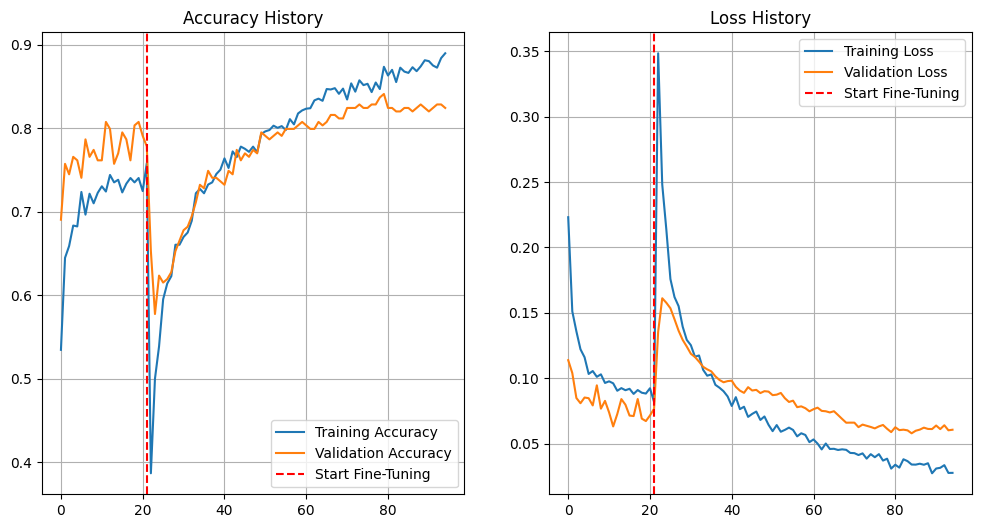

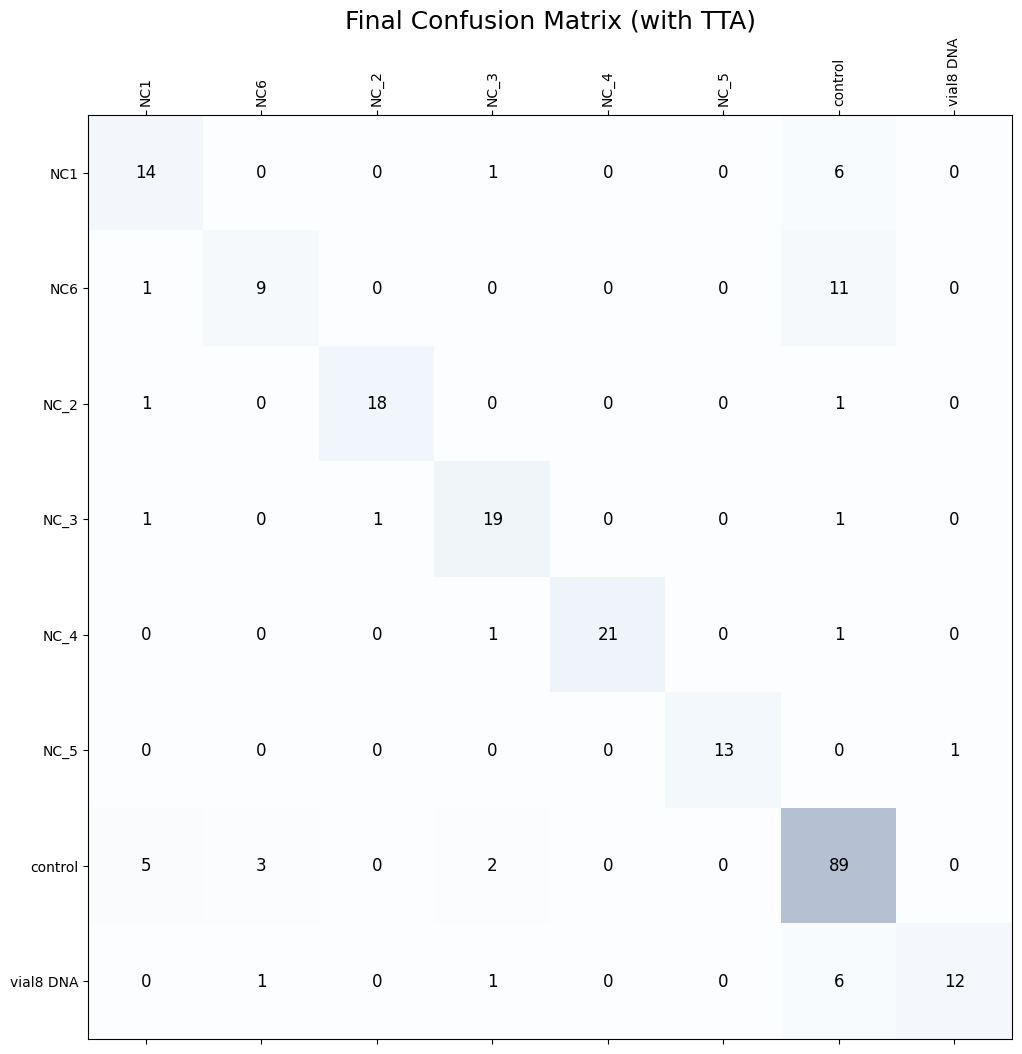


✅ All outputs have been saved to the directory: /kaggle/working/

--- HOW TO DOWNLOAD YOUR FILES ---
1. After the notebook finishes, go to the 'Output' section in the right sidebar.
2. Find the '/kaggle/working' directory.
3. You will see 'final_model_finetuned.h5', 'final_model_finetuned.weights.h5', and your graphs.
4. Click the '...' menu next to each file and select 'Download' to save them to your computer.


In [3]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
# Path to the dataset provided by Kaggle
INPUT_DIR = "/kaggle/input/biofilm-dataset"
# Writable directory for processed data and all final outputs
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters for a more powerful model
IMG_SIZE = (300, 300) # EfficientNetB3 performs better with larger images
BATCH_SIZE = 16       # Smaller batch size for a larger model
INITIAL_EPOCHS = 50
FINETUNE_EPOCHS = 50
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5    # Very low learning rate for stable fine-tuning

# ===================================================================
# STEP 2: COMBINE ALL DATA AND CREATE NEW, BALANCED SPLITS
# ===================================================================
print("--- Combining all images and labels from the original dataset ---")
all_image_paths = []
all_labels = []

# Find and parse all COCO json files to collect all available data
coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    if "_annotations.coco.json" in files:
        subset = os.path.basename(root)
        coco_files[subset] = os.path.join(root, "_annotations.coco.json")

for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name']), 'label_id': ann['category_id']}
                      for img in coco_data['images'] for ann in coco_data['annotations'] if ann['image_id'] == img['id']}
                      
    for img_id, info in img_id_to_info.items():
        if os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(cat_id_to_name[info['label_id']])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}, Total unique classes: {len(all_class_names)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE FINAL STRUCTURED DATASET
# ===================================================================
if os.path.exists(FINAL_DATASET_DIR): shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for path, label in zip(paths, labels):
        os.makedirs(os.path.join(subset_dir, label), exist_ok=True)
        shutil.copy(path, os.path.join(subset_dir, label, os.path.basename(path)))
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels)
create_subset("valid", val_paths, val_labels)
create_subset("test", test_paths, test_labels)

# ===================================================================
# STEP 4: DATA LOADERS AND FOCAL LOSS
# ===================================================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False).prefetch(buffer_size=AUTOTUNE)

# Focal Loss Implementation to combat class imbalance
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(all_class_names))
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        loss = -alpha * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return focal_loss_fn

# ===================================================================
# STEP 5: BUILD AND TRAIN THE MODEL (TWO-STAGE FINE-TUNING)
# ===================================================================
print("\n--- Building model with EfficientNetB3 ---")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5), layers.RandomZoom(0.5), layers.RandomContrast(0.4)
], name="data_augmentation")

base_model = applications.EfficientNetB3(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=INITIAL_LR), loss=focal_loss(), metrics=['accuracy'])

print("\n--- Starting Phase 1 Training (Feature Extraction) ---")
history = model.fit(train_ds, epochs=INITIAL_EPOCHS, validation_data=val_ds,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])
initial_epochs_trained = len(history.history['loss'])

print("\n--- Starting Phase 2 Training (Fine-Tuning) ---")
base_model.trainable = True
model.compile(optimizer=optimizers.Adam(learning_rate=FINETUNE_LR), loss=focal_loss(), metrics=['accuracy'])
history_fine_tune = model.fit(train_ds, epochs=INITIAL_EPOCHS + FINETUNE_EPOCHS, initial_epoch=initial_epochs_trained, validation_data=val_ds,
                              callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])

# ===================================================================
# STEP 6: EVALUATION WITH TEST-TIME AUGMENTATION (TTA)
# ===================================================================
print("\n--- Final Evaluation with Test-Time Augmentation ---")
tta_steps = 5
tta_predictions = []
test_images_ds = test_ds.map(lambda image, label: image)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

for _ in range(tta_steps):
    predictions = model.predict(test_images_ds)
    tta_predictions.append(predictions)

avg_predictions = np.mean(tta_predictions, axis=0)
y_pred = np.argmax(avg_predictions, axis=1)

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Final TTA Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final TTA Test F1-Score (Macro): {f1_macro:.4f}")
print("\nFinal TTA Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 7: SAVE ARTIFACTS AND VISUALIZE
# ===================================================================
print("\n--- Saving final model and visualizations ---")
model.save(os.path.join(OUTPUT_DIR, "final_model_finetuned.h5"))
model.save_weights(os.path.join(OUTPUT_DIR, "final_model_finetuned.weights.h5"))

# Combine histories for plotting
acc = history.history.get('accuracy', []) + history_fine_tune.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', []) + history_fine_tune.history.get('val_accuracy', [])
loss = history.history.get('loss', []) + history_fine_tune.history.get('loss', [])
val_loss = history.history.get('val_loss', []) + history_fine_tune.history.get('val_loss', [])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
if initial_epochs_trained > 0:
    plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Accuracy History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
if initial_epochs_trained > 0:
    plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Loss History')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()

all_labels_for_cm = list(range(len(all_class_names)))
cm = confusion_matrix(y_true, y_pred, labels=all_labels_for_cm)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix (with TTA)', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_final.png"))
plt.show()

print(f"\n✅ All outputs have been saved to the directory: {OUTPUT_DIR}")
print("\n--- HOW TO DOWNLOAD YOUR FILES ---")
print("1. After the notebook finishes, go to the 'Output' section in the right sidebar.")
print("2. Find the '/kaggle/working' directory.")
print("3. You will see 'final_model_finetuned.h5', 'final_model_finetuned.weights.h5', and your graphs.")
print("4. Click the '...' menu next to each file and select 'Download' to save them to your computer.")

In [3]:
import os
from IPython.display import FileLink

# ===================================================================
# FINAL STEP: GENERATE DOWNLOAD LINKS FOR ALL OUTPUT FILES
# ===================================================================
OUTPUT_DIR = "/kaggle/working/"

print(f"--- Generating Download Links for Files in: {OUTPUT_DIR} ---")

# List all files in the output directory
output_files = os.listdir(OUTPUT_DIR)

if not output_files:
    print("No files found in the output directory to download.")
else:
    for filename in output_files:
        file_path = os.path.join(OUTPUT_DIR, filename)
        if os.path.isfile(file_path):
            print(f"-> Click the link to download: {filename}")
            display(FileLink(file_path))

print("\n✅ Download links generated successfully.")

--- Generating Download Links for Files in: /kaggle/working/ ---

✅ Download links generated successfully.


2025-07-23 13:47:36.104215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753278456.305616      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753278456.363480      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


--- Combining all images and labels from the original dataset ---
Total combined images: 2393, Total unique classes: 8
Created 'train' subset with 1914 images.
Created 'valid' subset with 239 images.
Created 'test' subset with 240 images.
Found 1914 files belonging to 8 classes.


I0000 00:00:1753278482.935610      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753278482.936269      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 239 files belonging to 8 classes.
Found 240 files belonging to 8 classes.

--- Building model with EfficientNetB4 ---
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Starting Phase 1 Training (Feature Extraction) ---
Epoch 1/40


E0000 00:00:1753278516.784755      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb4_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1753278520.099988     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

 Trainable params: 18,470,736 (70.46 MB)

 Non-trainable params: 125,207 (489.09 KB)

Epoch 41/80


E0000 00:00:1753280195.799542      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb4_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


240/240 ━━━━━━━━━━━━━━━━━━━━ 281s 703ms/step - accuracy: 0.4558 - loss: 1.9839 - val_accuracy: 0.6318 - val_loss: 0.7227
Epoch 42/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 161s 673ms/step - accuracy: 0.5188 - loss: 1.0831 - val_accuracy: 0.5900 - val_loss: 0.5405
Epoch 43/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 162s 674ms/step - accuracy: 0.5578 - loss: 0.6949 - val_accuracy: 0.6736 - val_loss: 0.4299
Epoch 44/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 161s 672ms/step - accuracy: 0.5887 - loss: 0.5559 - val_accuracy: 0.6569 - val_loss: 0.3929
Epoch 45/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 162s 673ms/step - accuracy: 0.6355 - loss: 0.4574 - val_accuracy: 0.6736 - val_loss: 0.3792
Epoch 46/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 162s 674ms/step - accuracy: 0.6486 - loss: 0.4457 - val_accuracy: 0.6778 - val_loss: 0.3466
Epoch 47/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 161s 672ms/step - accuracy: 0.6529 - loss: 0.4352 - val_accuracy: 0.6820 - val_loss: 0.3316
Epoch 48/80
240/240 ━━━━━━━━━━━━━━━━━━━━ 161s 672ms/step - accuracy: 0.6758 - los

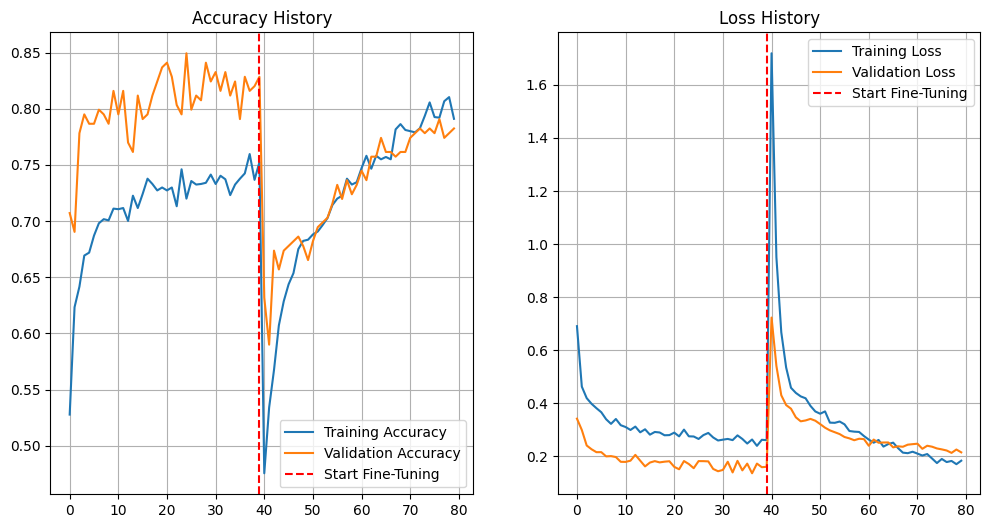

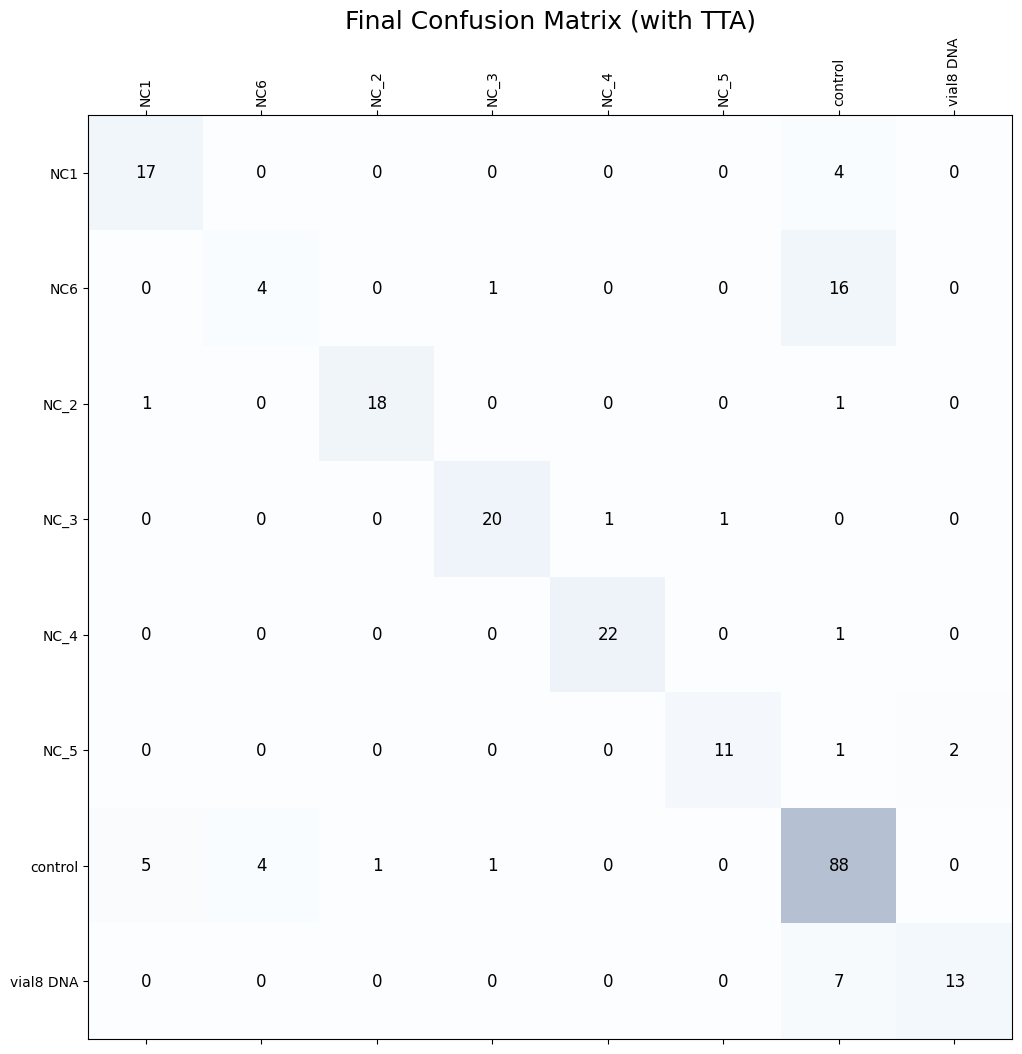


--- Creating a zip archive of all output files for download ---


OSError: [Errno 28] No space left on device

In [1]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from IPython.display import FileLink

# ===================================================================
# STEP 1: CONFIGURATION & PATHS
# ===================================================================
# Path to the dataset provided by Kaggle
INPUT_DIR = "/kaggle/input/biofilm-dataset"
# Writable directory for processed data and all final outputs
OUTPUT_DIR = "/kaggle/working/"
FINAL_DATASET_DIR = os.path.join(OUTPUT_DIR, "biofilm_dataset_final")

# Hyperparameters for a more powerful model and training strategy
IMG_SIZE = (380, 380) # Optimal for EfficientNetB4
BATCH_SIZE = 8        # Smaller batch size for a larger model
INITIAL_EPOCHS = 40
FINETUNE_EPOCHS = 40
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5    # Very low learning rate for stable fine-tuning

# ===================================================================
# STEP 2: COMBINE ALL DATA AND CREATE NEW, BALANCED SPLITS
# ===================================================================
print("--- Combining all images and labels from the original dataset ---")
all_image_paths = []
all_labels = []

# Find and parse all COCO json files to collect all available data
coco_files = {}
for root, dirs, files in os.walk(INPUT_DIR):
    if "_annotations.coco.json" in files:
        subset = os.path.basename(root)
        coco_files[subset] = os.path.join(root, "_annotations.coco.json")

for subset, coco_path in coco_files.items():
    image_dir = os.path.dirname(coco_path)
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    img_id_to_info = {img['id']: {'path': os.path.join(image_dir, img['file_name']), 'label_id': ann['category_id']}
                      for img in coco_data['images'] for ann in coco_data['annotations'] if ann['image_id'] == img['id']}
                      
    for img_id, info in img_id_to_info.items():
        if os.path.exists(info['path']):
            all_image_paths.append(info['path'])
            all_labels.append(cat_id_to_name[info['label_id']])

all_class_names = sorted(list(set(all_labels)))
print(f"Total combined images: {len(all_image_paths)}, Total unique classes: {len(all_class_names)}")

# Perform a new stratified split to ensure all classes are in all sets
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# ===================================================================
# STEP 3: CREATE FINAL STRUCTURED DATASET
# ===================================================================
if os.path.exists(FINAL_DATASET_DIR): shutil.rmtree(FINAL_DATASET_DIR)

def create_subset(dir_name, paths, labels):
    subset_dir = os.path.join(FINAL_DATASET_DIR, dir_name)
    for path, label in zip(paths, labels):
        os.makedirs(os.path.join(subset_dir, label), exist_ok=True)
        shutil.copy(path, os.path.join(subset_dir, label, os.path.basename(path)))
    print(f"Created '{dir_name}' subset with {len(paths)} images.")

create_subset("train", train_paths, train_labels)
create_subset("valid", val_paths, val_labels)
create_subset("test", test_paths, test_labels)

# ===================================================================
# STEP 4: DATA LOADERS AND FOCAL LOSS
# ===================================================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "valid"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int').prefetch(buffer_size=AUTOTUNE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DATASET_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False).prefetch(buffer_size=AUTOTUNE)

# Focal Loss Implementation to aggressively target class imbalance
def focal_loss(gamma=2.0, alpha=0.75): # Alpha > 0.5 gives more weight to minority classes
    def focal_loss_fn(y_true, y_pred):
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(all_class_names))
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        loss = -alpha * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return focal_loss_fn

# ===================================================================
# STEP 5: BUILD AND TRAIN THE MODEL (TWO-STAGE FINE-TUNING)
# ===================================================================
print("\n--- Building model with EfficientNetB4 ---")
# Aggressive data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.6), layers.RandomZoom(0.6), layers.RandomContrast(0.4)
], name="data_augmentation")

# Load a more powerful base model
base_model = applications.EfficientNetB4(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(all_class_names), activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=INITIAL_LR), loss=focal_loss(), metrics=['accuracy'])

print("\n--- Starting Phase 1 Training (Feature Extraction) ---")
history = model.fit(train_ds, epochs=INITIAL_EPOCHS, validation_data=val_ds,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])
initial_epochs_trained = len(history.history['loss'])

print("\n--- Starting Phase 2 Training (Fine-Tuning) ---")
base_model.trainable = True # Unfreeze all layers for a gentle fine-tune
model.compile(optimizer=optimizers.Adam(learning_rate=FINETUNE_LR), loss=focal_loss(), metrics=['accuracy'])
model.summary()

history_fine_tune = model.fit(train_ds, epochs=INITIAL_EPOCHS + FINETUNE_EPOCHS, initial_epoch=initial_epochs_trained, validation_data=val_ds,
                              callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")])

# ===================================================================
# STEP 6: EVALUATION WITH TEST-TIME AUGMENTATION (TTA)
# ===================================================================
print("\n--- Final Evaluation with Test-Time Augmentation ---")
tta_steps = 5
tta_predictions = []
test_images_ds = test_ds.map(lambda image, label: image)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

for _ in range(tta_steps):
    predictions = model.predict(test_images_ds)
    tta_predictions.append(predictions)

avg_predictions = np.mean(tta_predictions, axis=0)
y_pred = np.argmax(avg_predictions, axis=1)

# Evaluate all three sets for the final report
train_acc = model.evaluate(train_ds, verbose=0)[1]
val_acc = model.evaluate(val_ds, verbose=0)[1]
test_acc_tta = accuracy_score(y_true, y_pred)
f1_macro_tta = f1_score(y_true, y_pred, average='macro')

print("\n--- FINAL PERFORMANCE METRICS ---")
print(f"Final Training Accuracy:   {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Final TTA Test Accuracy:   {test_acc_tta * 100:.2f}%")
print(f"Final TTA Test F1-Score (Macro): {f1_macro_tta:.4f}")
print("\nFinal TTA Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=all_class_names, zero_division=0))

# ===================================================================
# STEP 7: SAVE ARTIFACTS AND VISUALIZE
# ===================================================================
print("\n--- Saving final model and visualizations ---")
model.save(os.path.join(OUTPUT_DIR, "final_model.h5"))
model.save_weights(os.path.join(OUTPUT_DIR, "final_model.weights.h5"))

# Combine histories for plotting
acc = history.history.get('accuracy', []) + history_fine_tune.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', []) + history_fine_tune.history.get('val_accuracy', [])
loss = history.history.get('loss', []) + history_fine_tune.history.get('loss', [])
val_loss = history.history.get('val_loss', []) + history_fine_tune.history.get('val_loss', [])

# Save metrics to a CSV file for your records
metrics_df = pd.DataFrame({
    'accuracy': acc, 'val_accuracy': val_acc, 'loss': loss, 'val_loss': val_loss
})
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "training_metrics.csv"), index=False)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
if initial_epochs_trained > 0:
    plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Accuracy History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
if initial_epochs_trained > 0:
    plt.axvline(initial_epochs_trained - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Loss History')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()

all_labels_for_cm = list(range(len(all_class_names)))
cm = confusion_matrix(y_true, y_pred, labels=all_labels_for_cm)
fig, ax = plt.subplots(figsize=(12, 12))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='large')
plt.xticks(range(len(all_class_names)), all_class_names, rotation=90)
plt.yticks(range(len(all_class_names)), all_class_names)
plt.title('Final Confusion Matrix (with TTA)', fontsize=18)
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_final.png"))
plt.show()

# ===================================================================
# STEP 8: CREATE ZIP ARCHIVE AND GENERATE DOWNLOAD LINK
# ===================================================================
print("\n--- Creating a zip archive of all output files for download ---")
archive_path = "/kaggle/working/biofilm_results"
shutil.make_archive(archive_path, 'zip', OUTPUT_DIR)

print(f"\n✅ All outputs have been saved and zipped to: {archive_path}.zip")
print("\n--- Click the Link Below to Download Your Results ---")

# Generate a single, reliable download link for the zip file
display(FileLink(f"{archive_path}.zip"))

--- Generating download links for your result files ---
Error: The file was not found at '/kaggle/working/final_model_finetuned.h5'. Please check the path and spelling.
Error: The file was not found at '/kaggle/working/final_model_finetuned.weights.h5'. Please check the path and spelling.
-> Click the link below to download: training_history.png


/kaggle/working/training_history.png

-> Click the link below to download: confusion_matrix_final.png


/kaggle/working/confusion_matrix_final.png